# 📋 INSTRUCTOR NOTEBOOK — Sequence Models: RNNs, LSTMs, and Model Comparison

**Module 0 · Lesson 10 of 13 · Instructor edition**  
**Estimated class time:** 90–110 minutes  
**Source sequence:** Original Day 3  

**Prerequisite:** Lessons 7–9  

> **Do not distribute to students.** This edition contains solutions, teaching notes, and model answers.

## Learning objectives

By the end of this lesson, you should be able to:

- Explain hidden state, recurrence, and vanishing gradients.
- Implement and train RNN and LSTM forecasters.
- Compare classical, tree-based, MLP, RNN, and LSTM forecasts.

## Setup for this lesson

This cell recreates the data and completed prerequisites from earlier lessons, so this notebook can be run in a fresh kernel.

In [ ]:
# Shared forecasting setup from the preceding lesson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date', 'Passengers']
df['Log_Passengers'] = np.log(df['Passengers'])
df['Log_Diff'] = df['Log_Passengers'].diff()
series = df['Log_Diff'].dropna().values

def make_lag_matrix(series, n_lags):
    series = np.asarray(series)
    X, y = [], []
    for t in range(n_lags, len(series)):
        X.append(series[t - n_lags:t])
        y.append(series[t])
    return np.asarray(X), np.asarray(y)

N_LAGS = 12
X, y = make_lag_matrix(series, N_LAGS)
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

naive_preds = np.concatenate([[y_train[-1]], y_test[:-1]])
train_series = series[:split + N_LAGS]
ar_result = AutoReg(train_series, lags=N_LAGS).fit()
ar_preds = ar_result.predict(
    start=len(train_series),
    end=len(train_series) + len(y_test) - 1,
    dynamic=False,
)


rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

gb_model = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, random_state=42
)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

def compute_metrics(y_true, y_pred, label='Model'):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f'{label:<30}  RMSE={rmse:.5f}   MAE={mae:.5f}')
    return {'RMSE': rmse, 'MAE': mae}

results = {
    'Naive Baseline': compute_metrics(y_test, naive_preds, 'Naive Baseline'),
    'AR(12)': compute_metrics(y_test, ar_preds, 'AR(12)'),
    'Random Forest': compute_metrics(y_test, rf_preds, 'Random Forest'),
    'Gradient Boosting': compute_metrics(y_test, gb_preds, 'Gradient Boosting'),
}


scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)

class MLPForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp = MLPForecaster(input_size=N_LAGS, hidden_size=32)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
for _ in range(300):
    mlp.train()
    optimizer.zero_grad()
    loss = loss_fn(mlp(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()

mlp.eval()
with torch.no_grad():
    mlp_preds_s = mlp(X_test_t).numpy()
mlp_preds = scaler_y.inverse_transform(mlp_preds_s.reshape(-1, 1)).ravel()
results['MLP'] = compute_metrics(y_test, mlp_preds, 'MLP')


---
## 📣 Segment 6 — RNN & LSTM: Hidden State, Recurrence, and Gating (50 min)

### Why RNNs?

The MLP receives a flat lag vector and treats the lags as unordered features. An **RNN
(Recurrent Neural Network)** processes the sequence *one step at a time*, maintaining a
**hidden state** that is updated at each step. This allows the model to explicitly encode
the *sequential* nature of the data.

### The RNN Recurrence Equation

At each time step $t$, an RNN computes:

$$\mathbf{h}_t = \tanh(W_{hh}\,\mathbf{h}_{t-1} + W_{xh}\,\mathbf{x}_t + \mathbf{b}_h)$$

where:
- $\mathbf{x}_t \in \mathbb{R}^d$ is the input at step $t$ (here, the value at lag $t$)
- $\mathbf{h}_t \in \mathbb{R}^H$ is the **hidden state** — a learned summary of the
  sequence up to step $t$
- $W_{hh}$ is the **recurrent weight matrix** connecting hidden states
- $W_{xh}$ is the **input weight matrix**
- $\mathbf{h}_0 = \mathbf{0}$ (zero initialization)

After processing all $p$ lags, the final hidden state $\mathbf{h}_p$ is passed through
a linear output layer to produce the forecast:

$$\hat{y} = W_o \mathbf{h}_p + b_o$$

**Key insight:** The hidden state is a compressed representation of the entire sequence
history. Unlike the MLP (which ignores order), the RNN builds this representation
incrementally, step by step.

### The Vanishing Gradient Problem

When training an RNN via backpropagation through time (BPTT), gradients must flow
backward through the recurrence:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{h}_0} \propto \prod_{t=1}^{p} W_{hh}^\top$$

If the eigenvalues of $W_{hh}$ are less than 1, this product **vanishes** exponentially
with $p$ — the model fails to learn long-range dependencies. If they are greater than 1,
gradients **explode**.

### The LSTM Solution: Gating Mechanisms

The **LSTM (Long Short-Term Memory)** introduces a **cell state** $\mathbf{c}_t$ and
three **gates** that control information flow:

$$\mathbf{f}_t = \sigma(W_f [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f) \quad \text{(forget gate)}$$
$$\mathbf{i}_t = \sigma(W_i [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i) \quad \text{(input gate)}$$
$$\mathbf{o}_t = \sigma(W_o [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o) \quad \text{(output gate)}$$
$$\tilde{\mathbf{c}}_t = \tanh(W_c [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_c) \quad \text{(candidate cell)}$$
$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t \quad \text{(cell update)}$$
$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t) \quad \text{(hidden state)}$$

where $\sigma$ is the sigmoid, $\odot$ is element-wise multiplication, and the cell state
$\mathbf{c}_t$ can **carry gradients across many time steps** without vanishing, because
the forget gate $\mathbf{f}_t$ allows the gradient to flow through additively rather
than multiplicatively.

### Talking Points
- **Analogy for the cell state:** Think of $\mathbf{c}_t$ as a "conveyor belt" — it can
  carry information across many steps almost unchanged. The gates decide what to load,
  what to drop, and what to read off.
- **Forget gate intuiton:** $\mathbf{f}_t \approx 1$ means 'keep everything from the
  previous cell state'. $\mathbf{f}_t \approx 0$ means 'forget it'.
- **When does LSTM beat RNN?** Primarily when long-range dependencies matter (e.g., lag-12
  still matters after 12 steps of recurrence). For short sequences the difference is small.
- **Connection to AR:** Both RNN and LSTM are, at their core, extending the linear AR
  memory model to non-linear, learned memory.

### Dividir y Confluir — Group Activity

**Assign groups to experiment with RNN architecture choices:**
- Group A: `hidden_size=16`
- Group B: `hidden_size=32`
- Group C: `hidden_size=64`
- Group D: Two LSTM layers (`num_layers=2`) vs one

Groups compare final RMSE/MAE. Discussion: Does adding capacity always help on this small
dataset? Why might the LSTM not dramatically outperform the MLP here?

### ⚠️ Common Mistakes
- **RNN input shape:** PyTorch RNN/LSTM expect `(batch, seq_len, input_size)`. From our
  lag matrix, we have `(batch, n_lags)` — we need to unsqueeze a dimension:
  `x.unsqueeze(-1)` makes it `(batch, n_lags, 1)` treating each lag as a 1-D input.
- **Hidden state initialization:** For evaluation, reset the hidden state. PyTorch does
  this by default when `h_0` is not passed.
- **Exploding gradients:** If loss is NaN, try gradient clipping:
  `nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)`.

In [ ]:
# ── SOLUTION: RNN model ──────────────────────────────────────────────────────
class RNNForecaster(nn.Module):
    """
    Single-layer Elman RNN for time series forecasting.

    Processes the lag sequence step-by-step and produces a single
    scalar forecast from the final hidden state.

    Parameters
    ----------
    input_size  : int, features per time step (1 for univariate)
    hidden_size : int, hidden state dimension
    """
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)  # SOLUTION
        self.fc  = nn.Linear(hidden_size, 1)                          # SOLUTION

    def forward(self, x):
        # x: (batch, n_lags) → unsqueeze → (batch, n_lags, 1)
        x = x.unsqueeze(-1)                      # SOLUTION
        _, h_n = self.rnn(x)                     # h_n: (1, batch, hidden)
        h_n = h_n.squeeze(0)                     # (batch, hidden)
        return self.fc(h_n).squeeze(-1)           # SOLUTION

In [ ]:
# ── SOLUTION: LSTM model ─────────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    """
    Single-layer LSTM for time series forecasting.

    Extends the RNN with a cell state and gating mechanisms, allowing
    the model to selectively retain or forget information across lags.

    Parameters
    ----------
    input_size  : int, features per time step (1 for univariate)
    hidden_size : int, hidden/cell state dimension
    """
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)  # SOLUTION
        self.fc   = nn.Linear(hidden_size, 1)                           # SOLUTION

    def forward(self, x):
        x = x.unsqueeze(-1)                          # (batch, n_lags, 1)
        _, (h_n, _) = self.lstm(x)                   # h_n: (1, batch, hidden)
        h_n = h_n.squeeze(0)                         # (batch, hidden)
        return self.fc(h_n).squeeze(-1)              # SOLUTION

RNN — final loss: 0.014996
LSTM — final loss: 0.040723


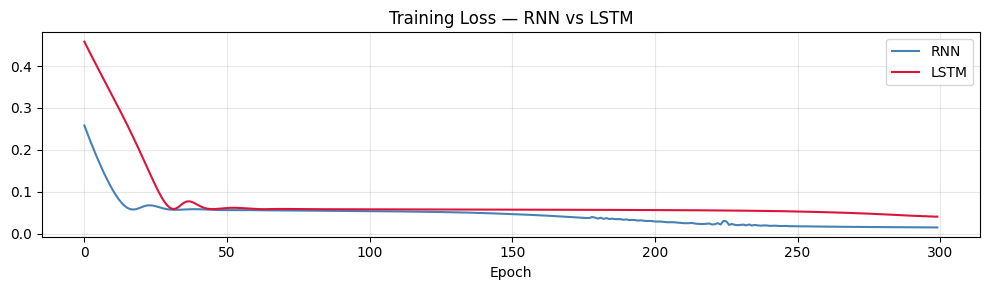

In [ ]:
# ── SOLUTION: Generic training function ────────────────────────────────────
def train_model(model, X_t, y_t, epochs=300, lr=1e-3, label='Model'):
    """
    Train a PyTorch model with MSE loss and Adam optimizer.

    Parameters
    ----------
    model  : nn.Module
    X_t    : torch.Tensor, (n_samples, n_lags)
    y_t    : torch.Tensor, (n_samples,)
    epochs : int
    lr     : float, learning rate
    label  : str, for display

    Returns
    -------
    list of training losses
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()
    losses    = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_t)              # SOLUTION
        loss = loss_fn(pred, y_t)      # SOLUTION
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())

    print(f'{label} — final loss: {losses[-1]:.6f}')
    return losses


rnn_model  = RNNForecaster(hidden_size=32)
lstm_model = LSTMForecaster(hidden_size=32)

rnn_losses  = train_model(rnn_model,  X_train_t, y_train_t, epochs=300, label='RNN')
lstm_losses = train_model(lstm_model, X_train_t, y_train_t, epochs=300, label='LSTM')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(rnn_losses,  label='RNN',  color='steelblue')
ax.plot(lstm_losses, label='LSTM', color='crimson')
ax.set_title('Training Loss — RNN vs LSTM')
ax.set_xlabel('Epoch')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── SOLUTION: Evaluate RNN & LSTM ───────────────────────────────────────────
def eval_model(model, X_t, scaler_y):
    """
    Generate predictions and inverse-transform to original scale.

    Parameters
    ----------
    model    : trained nn.Module
    X_t      : torch.Tensor, test features
    scaler_y : fitted MinMaxScaler for the target

    Returns
    -------
    np.ndarray of predictions in original (log-diff) scale
    """
    model.eval()
    with torch.no_grad():
        preds_s = model(X_t).numpy()                              # SOLUTION
    return scaler_y.inverse_transform(preds_s.reshape(-1, 1)).ravel()  # SOLUTION


rnn_preds  = eval_model(rnn_model,  X_test_t, scaler_y)
lstm_preds = eval_model(lstm_model, X_test_t, scaler_y)

results['RNN']  = compute_metrics(y_test, rnn_preds,  'RNN')
results['LSTM'] = compute_metrics(y_test, lstm_preds, 'LSTM')

RNN                             RMSE=0.05694   MAE=0.04973
LSTM                            RMSE=0.08494   MAE=0.07376


---
## 📣 Segment 7 — Full Model Comparison & Synthesis (30 min)

### Talking Points
- Bring the **dividir y confluir** groups back together. Each group shares their model's
  RMSE/MAE and one observation about training behaviour.
- Build the comparison table together on the board before revealing the code output.
- **Key question to drive discussion:** *"Why might the simplest models be competitive or
  even better on this particular dataset?"*
  - Air Passengers is a small dataset (143 observations after differencing).
  - The signal is largely linear (seasonal AR structure).
  - Neural networks need more data to realize their advantage.
  - On larger, non-linear datasets the hierarchy would likely differ.
- **Preview for later in the week:** evaluation on *multi-step* horizons (where RNNs/LSTMs
  often shine), and hyperparameter tuning.

### ⚠️ Common Mistakes — Final Reflection
- **Declaring a 'winner' without caveats:** Push students to note dataset size, data
  characteristics, and computational cost when making recommendations.
- **Forgetting to interpret differences, not just report them:** RMSE of 0.056 vs 0.059
  needs context — is this meaningful or within noise?

In [ ]:
# ── SOLUTION: Full comparison table ─────────────────────────────────────────
comparison_df = pd.DataFrame(results).T                               # SOLUTION
comparison_df = comparison_df.sort_values('RMSE')                     # SOLUTION
print('\n=== Model Comparison (sorted by RMSE) ===')
print(comparison_df.to_string(float_format='{:.5f}'.format))


=== Model Comparison (sorted by RMSE) ===
                     RMSE     MAE
Random Forest     0.03929 0.03061
Gradient Boosting 0.04205 0.03437
AR(12)            0.04432 0.03242
MLP               0.04958 0.04013
RNN               0.05694 0.04973
LSTM              0.08494 0.07376
Naive Baseline    0.13377 0.11157


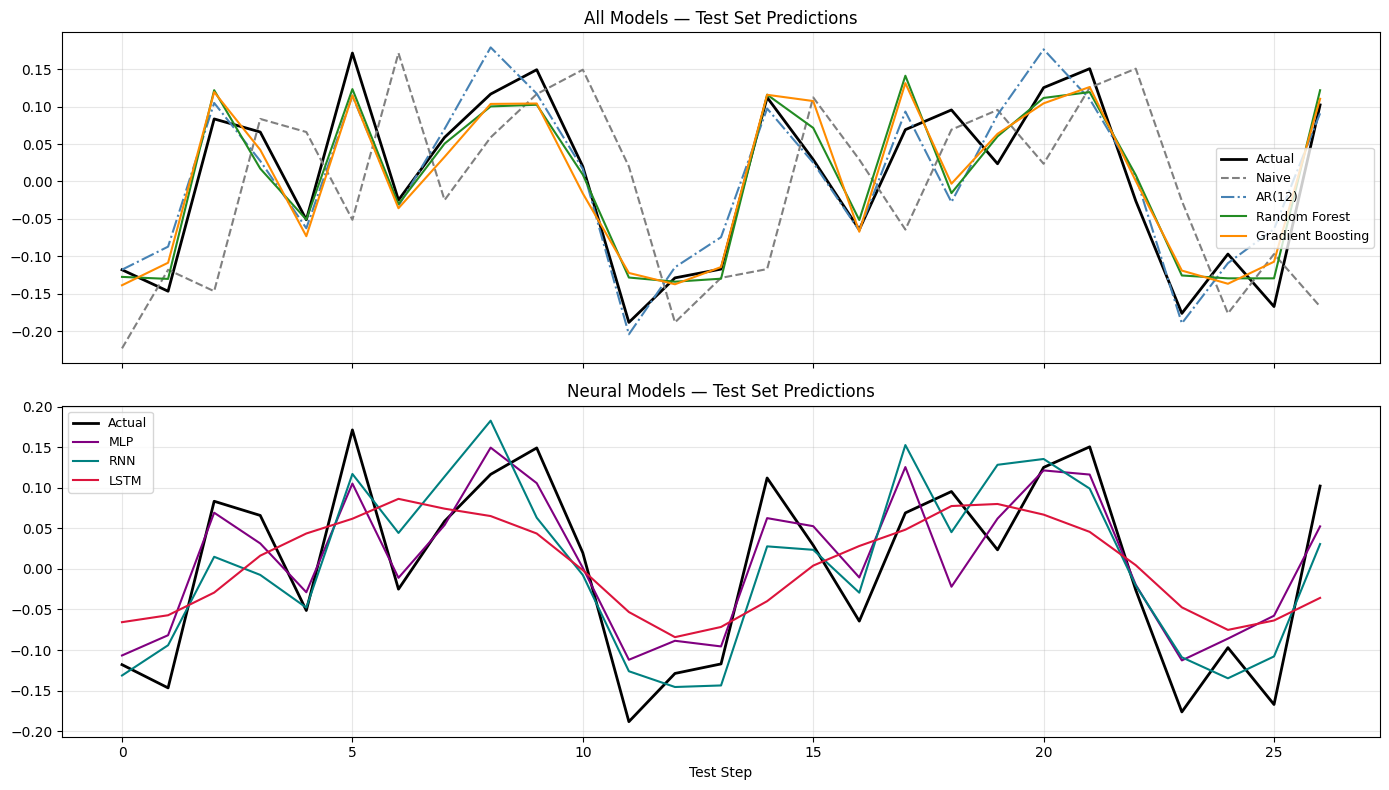

In [ ]:
# ── SOLUTION: Visual comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

test_range = np.arange(len(y_test))

# Top: all models
axes[0].plot(test_range, y_test,           label='Actual',            color='black', linewidth=2)
axes[0].plot(test_range, naive_preds,      label='Naive',             color='gray',        linestyle='--')
axes[0].plot(test_range, ar_preds,         label='AR(12)',            color='steelblue',   linestyle='-.')
axes[0].plot(test_range, rf_preds,         label='Random Forest',     color='forestgreen')
axes[0].plot(test_range, gb_preds,         label='Gradient Boosting', color='darkorange')
axes[0].set_title('All Models — Test Set Predictions')
axes[0].legend(fontsize=9)

# Bottom: neural models
axes[1].plot(test_range, y_test,           label='Actual', color='black', linewidth=2)
axes[1].plot(test_range, mlp_preds,        label='MLP',    color='purple')
axes[1].plot(test_range, rnn_preds,        label='RNN',    color='teal')
axes[1].plot(test_range, lstm_preds,       label='LSTM',   color='crimson')
axes[1].set_title('Neural Models — Test Set Predictions')
axes[1].set_xlabel('Test Step')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

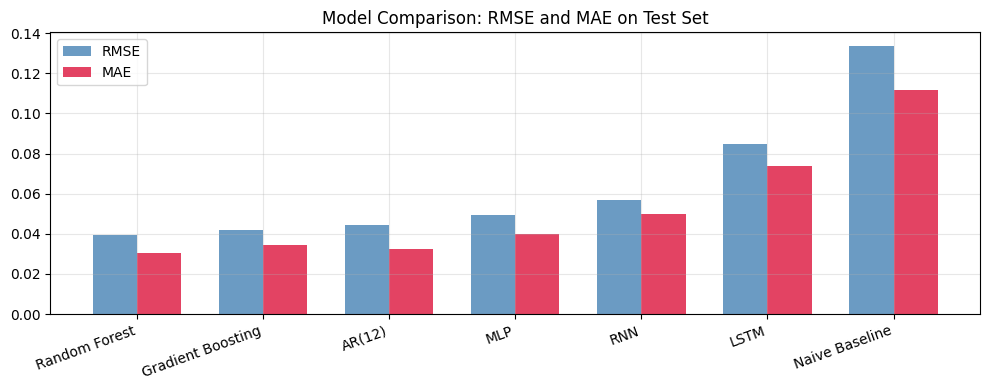

In [ ]:
# ── SOLUTION: Bar chart of RMSE ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
models  = list(comparison_df.index)
rmse_vals = comparison_df['RMSE'].values
mae_vals  = comparison_df['MAE'].values

x = np.arange(len(models))
w = 0.35
ax.bar(x - w/2, rmse_vals, w, label='RMSE', color='steelblue', alpha=0.8)
ax.bar(x + w/2, mae_vals,  w, label='MAE',  color='crimson',   alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_title('Model Comparison: RMSE and MAE on Test Set')
ax.legend()
plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Final Written Reflection

> Today we implemented and compared six forecasting model families on the Air Passengers
> log-differenced series. The **naive baseline** (predict last value) establishes the
> minimum bar: any model that can't beat it adds no value.
>
> The **AR(12) model** explicitly captures the seasonal lag-12 autocorrelation identified
> on Day 1, and typically out-performs the naive baseline. **Tree-based models** consume
> the same lag matrix but can capture non-linear patterns; on this relatively linear dataset
> they perform similarly to AR.
>
> The **MLP** applies non-linear transformations to the lag vector but ignores sequential
> ordering. The **RNN** and **LSTM** process the sequence step-by-step, maintaining a
> hidden state. The RNN can suffer from **vanishing gradients** over long sequences; the
> LSTM's **gating mechanisms** (forget, input, output gates) allow gradient to flow across
> many steps additively through the cell state.
>
> On this small dataset, simpler models are competitive because the signal is largely
> linear and data is limited. On larger, more non-linear datasets, neural models typically
> show stronger advantages.

---
## 🔚 End-of-Day Wrap-Up Notes

### What students should walk away knowing
1. Time series train/test splits must be chronological — never shuffle.
2. The naive baseline is the essential benchmark — beat it first.
3. The lag matrix from Day 2 is the universal input format for all non-AR models.
4. RMSE and MAE measure different things; report both.
5. RNNs process sequences with a hidden state; LSTMs extend this with gating to combat vanishing gradients.
6. Model performance must always be contextualized (dataset size, linearity, interpretability).

### Frequently Confused Pairs

| Students confuse... | Clarification |
|---|---|
| RMSE vs MAE | RMSE penalizes large errors more; MAE is linear in error magnitude |
| RNN hidden state vs LSTM cell state | Cell state is the 'long-term memory'; hidden state is the output |
| Forget gate ≈ 0 vs ≈ 1 | ≈ 1 means retain; ≈ 0 means forget (sigmoid output) |
| Scaling for trees vs networks | Trees: skip scaling. Networks: always scale |
| `dynamic=False` vs `dynamic=True` in AutoReg | False: use actual past values. True: chain own predictions |

### Preview for Tomorrow
> Tomorrow we deepen our understanding of sequence models, explore multi-step forecasting,
> and investigate hyperparameter sensitivity. We'll also revisit the full pipeline — from
> raw data to trained model — as an integrated workflow.